    Exploratory Analysis of an Electronic Nose Gas Sensor Dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_svmlight_file
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
# list to store all batches
all_batches = []

for i in range(1,11):
    X, y = load_svmlight_file(f"data/batch{i}.dat")
    df = pd.DataFrame(X.toarray())
    df["Gas_Class"] = y
    df["Batch"] = i
    all_batches.append(df)

data = pd.concat(all_batches, ignore_index=True)
# print(data.shape)

(13910, 130)


    INSPECT

In [14]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,Gas_Class,Batch
0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,...,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,1.0,1
1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,...,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,1.0,1
2,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,...,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,1.0,1
3,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,38379.0664,2.851173,...,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,1.0,1
4,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,51975.5899,3.480866,...,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,1.0,1


In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 130 entries, 0 to Batch
dtypes: float64(129), int64(1)
memory usage: 13.8 MB


In [16]:
data.describe

<bound method NDFrame.describe of                  0          1          2          3           4          5  \
0       15596.1621   1.868245   2.371604   2.803678    7.512213  -2.739388   
1       26402.0704   2.532401   5.411209   6.509906    7.658469  -4.722217   
2       42103.5820   3.454189   8.198175  10.508439   11.611003  -7.668313   
3       42825.9883   3.451192  12.113940  16.266853   39.910056  -7.849409   
4       58151.1757   4.194839  11.455096  15.715298   17.654915 -11.083364   
...            ...        ...        ...        ...         ...        ...   
13905   28929.5108   3.309200   4.393300   5.057000    9.423300  -3.879400   
13906   40392.1230   3.280000  10.268900  13.585900   20.979000  -8.173200   
13907  183271.5898  15.594500  45.480300  63.877500   81.139600 -29.539100   
13908   29059.8516   2.568000   6.714200   8.786500   13.987800  -6.041100   
13909  230762.7607  19.166600  60.936400  87.855700  117.341400 -36.421000   

               6           7 

In [18]:
data.isnull().sum()

0            0
1            0
2            0
3            0
4            0
            ..
125          0
126          0
127          0
Gas_Class    0
Batch        0
Length: 130, dtype: int64

    Exploratory Data Analysis
The combined dataset contains 13910 observations collected from 10 experimental batches. Each observation consists of 128 sensor features along with the corresponding gas class label and batch identifier.
We have seen that it contains no missing values

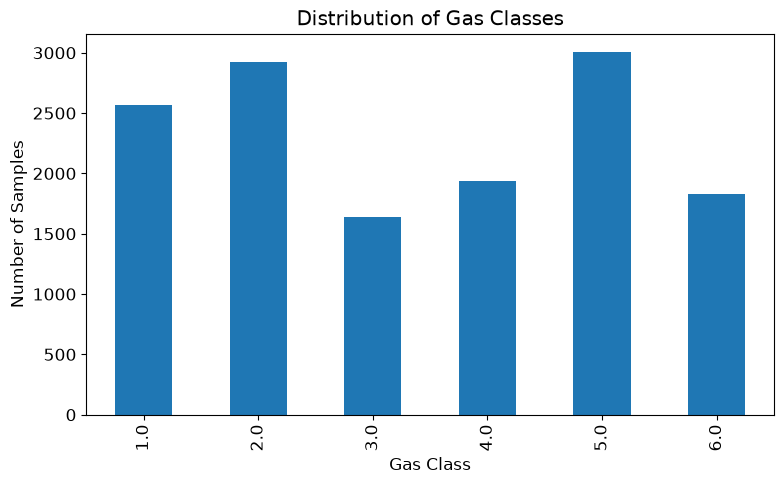

In [19]:
# Distribution of Gas Classes
gas_counts = data["Gas_Class"].value_counts().sort_index()

plt.figure(figsize=(8,5))
gas_counts.plot(kind = "bar")

plt.title("Distribution of Gas Classes")
plt.xlabel("Gas Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

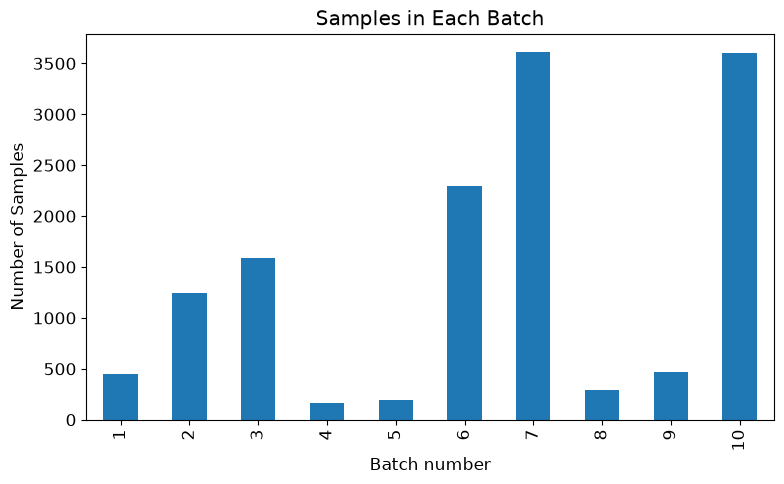

In [20]:
# Samples per Batch
batch_counts = data["Batch"].value_counts().sort_index()

plt.figure(figsize=(8,5))
batch_counts.plot(kind = "bar")

plt.title("Samples in Each Batch")
plt.xlabel("Batch number")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

    Correlation Analysis
To investigate relationships between sensor features, a correlation heatmap is generated. Since the dataset contains 128 sensor features, only the first 20 features are visualized to improve readability.

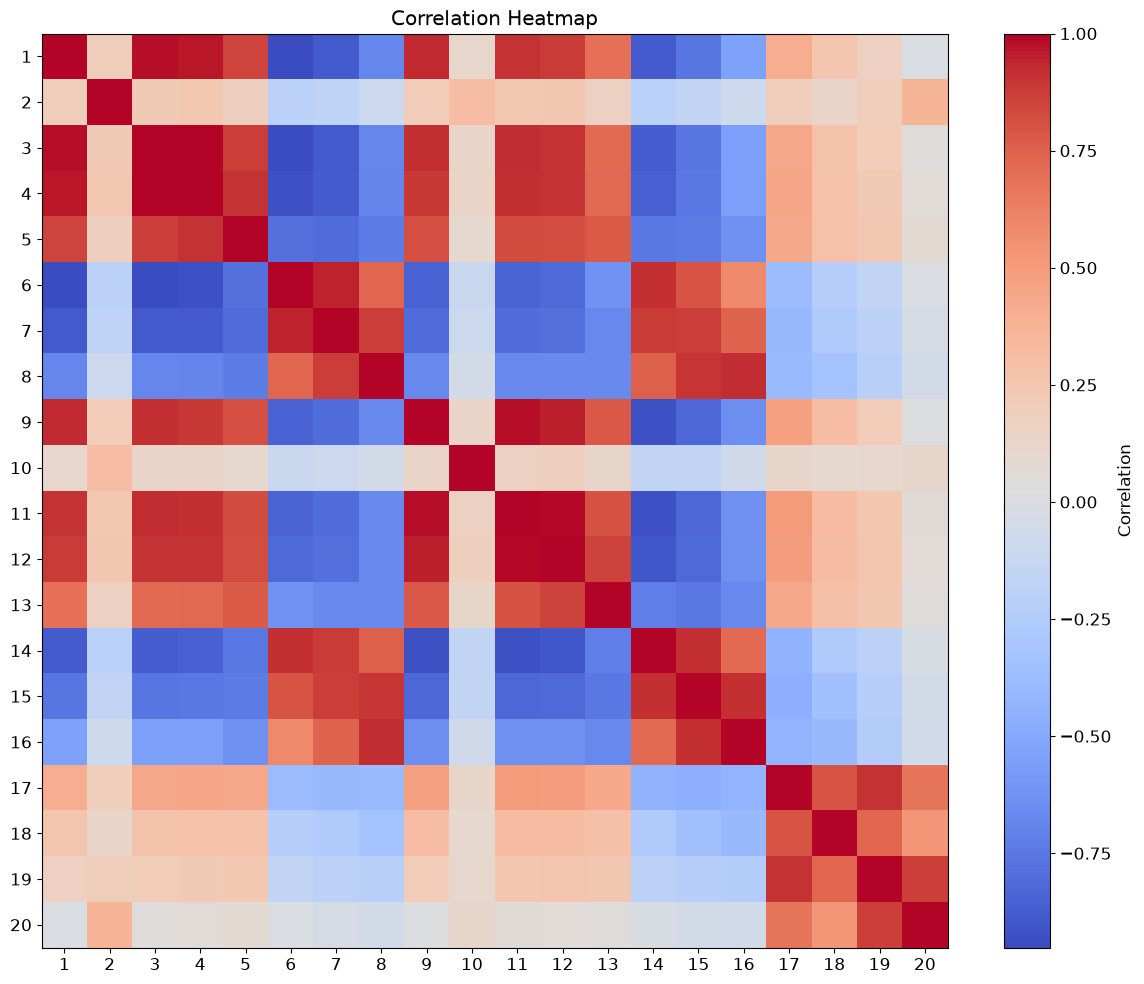

In [21]:
corr = data.iloc[:, :20].corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap = "coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.title("Correlation Heatmap")
plt.xticks(range(20), range(1,21))
plt.yticks(range(20), range(1,21))

plt.tight_layout()
plt.show()

    Principal Component Analysis (PCA)
This is used to reduce hgh-dimensional sensor data to two dimensions while preserving as much variance as possible. Here it can help visualize whether different gas classes exhibit distinct clustering patterns.

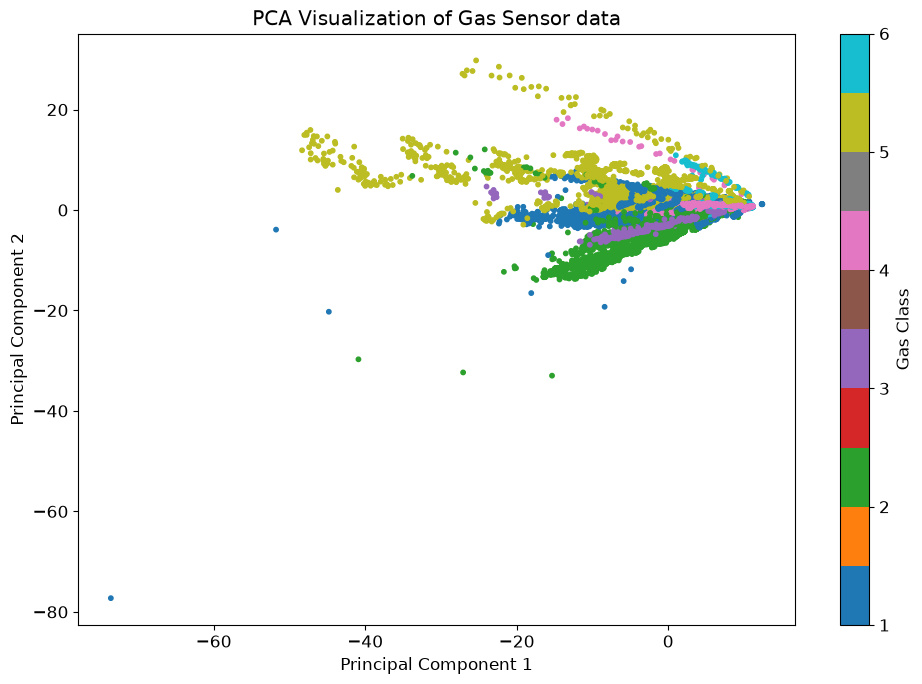

In [23]:
X = data.iloc[:, :-2]
y = data["Gas_Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="tab10",
    s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Gas Sensor data")
plt.colorbar(scatter,label="Gas Class")

plt.tight_layout()
plt.show()